# **1. Exploratory Data Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
update_files = [
    "../data/raw/tracks_popularity_day1.csv",
    "../data/raw/tracks_popularity_day2.csv",
    "../data/raw/tracks_popularity_day3.csv",
    "../data/raw/tracks_popularity_day4.csv",
    "../data/raw/tracks_popularity_day5.csv",
    "../data/raw/tracks_popularity_day6.csv"
]

In [3]:
df = pd.read_csv("../data/raw/spotify_songs.csv")

# Keep original popularity for comparison
df = df.rename(columns={"track_popularity": "old_popularity"})

In [4]:
df.duplicated(subset='track_id').sum()

np.int64(4477)

In [5]:
# drop duplicate rows based on 'track_id'
df = df.drop_duplicates(subset='track_id', keep='first').reset_index(drop=True)

In [6]:
#remove rows with missing values
df.dropna(inplace=True)
df.shape

(28352, 23)

In [7]:
# Load and combine updated popularity files
df_updates = pd.concat((pd.read_csv(f) for f in update_files), ignore_index=True)
df_updates = df_updates.rename(columns={"track_popularity": "updated_popularity"})


# Merge into main df
df = df.merge(df_updates, on="track_id", how="left")

In [8]:
df.to_csv("../data/raw/spotify_songs_with_new_popularity.csv", index=False)

In [9]:
# One-hot encode playlist_genre
genre_dummies = pd.get_dummies(df["playlist_genre"], prefix="genre", dtype=int)
df = pd.concat([df, genre_dummies], axis=1)
df.drop("playlist_genre", axis=1, inplace=True)

In [10]:
# One-hot encode key
key_dummies = pd.get_dummies(df["key"], prefix="key", dtype=int)
df = pd.concat([df, key_dummies], axis=1)
df.drop("key", axis=1, inplace=True)

In [11]:
# One-hot encode mode
mode_dummies = pd.get_dummies(df["mode"], prefix="mode", dtype=int)
df = pd.concat([df, mode_dummies], axis=1)
df.drop("mode", axis=1, inplace=True)

In [12]:
# Create song_age feature
df["track_album_release_date"] = pd.to_datetime(df["track_album_release_date"], errors='coerce')
df["song_age"] = (pd.Timestamp.today() - df["track_album_release_date"]).dt.days / 365
df.drop("track_album_release_date", axis=1, inplace=True)

In [13]:
df["song_age"].isna().sum()

np.int64(1681)

In [14]:
# Drop rows with missing song_age
df = df.dropna(subset=["song_age"])

In [15]:
# Convert duration from ms to minutes
df["duration_mn"]=df["duration_ms"]/60000
df = df.drop(columns=["duration_ms"])

In [16]:
#Dropping columns that won't be used in modeling
df = df.drop(columns=["track_id", "track_name", "track_artist","old_popularity","track_album_id","track_album_name",
 "playlist_id", "playlist_name","playlist_subgenre"])

In [17]:
df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,updated_popularity,...,key_6,key_7,key_8,key_9,key_10,key_11,mode_0,mode_1,song_age,duration_mn
0,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,43,...,1,0,0,0,0,0,0,1,6.553425,3.245900
1,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,42,...,0,0,0,0,0,1,0,1,6.054795,2.710000
2,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,45,...,0,0,0,0,0,0,1,0,6.495890,2.943600
3,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,38,...,0,1,0,0,0,0,0,1,6.457534,2.818217
4,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,63,...,0,0,0,0,0,0,0,1,6.830137,3.150867


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26671 entries, 0 to 28351
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   danceability        26671 non-null  float64
 1   energy              26671 non-null  float64
 2   loudness            26671 non-null  float64
 3   speechiness         26671 non-null  float64
 4   acousticness        26671 non-null  float64
 5   instrumentalness    26671 non-null  float64
 6   liveness            26671 non-null  float64
 7   valence             26671 non-null  float64
 8   tempo               26671 non-null  float64
 9   updated_popularity  26671 non-null  int64  
 10  genre_edm           26671 non-null  int64  
 11  genre_latin         26671 non-null  int64  
 12  genre_pop           26671 non-null  int64  
 13  genre_r&b           26671 non-null  int64  
 14  genre_rap           26671 non-null  int64  
 15  genre_rock          26671 non-null  int64  
 16  key_0    

In [19]:
df.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,updated_popularity,...,key_6,key_7,key_8,key_9,key_10,key_11,mode_0,mode_1,song_age,duration_mn
count,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,...,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000
mean,0.655497,0.698713,-6.742113,0.109072,0.177788,0.093692,0.190792,0.504557,121.017948,23.164711,...,0.080162,0.100371,0.073975,0.091260,0.070189,0.091148,0.439016,0.560984,13.417978,3.744909
std,0.144708,0.183401,3.001668,0.102986,0.223259,0.236079,0.155624,0.233927,26.891792,25.810516,...,0.271549,0.300500,0.261736,0.287984,0.255469,0.287824,0.496276,0.496276,10.306926,1.006738
min,0.000000,0.000175,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.926027,0.066667
25%,0.564000,0.580000,-8.206500,0.041400,0.014500,0.000000,0.092900,0.323000,99.984000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.723288,3.111342
50%,0.672000,0.722000,-6.197000,0.063700,0.080200,0.000020,0.127000,0.506000,122.010000,13.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.142466,3.585117
75%,0.761000,0.843000,-4.667000,0.136000,0.261000,0.007020,0.248000,0.688000,133.970000,44.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,15.698630,4.208967
max,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,95.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,69.043836,8.630167


In [20]:
df.columns.tolist()

['danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'updated_popularity',
 'genre_edm',
 'genre_latin',
 'genre_pop',
 'genre_r&b',
 'genre_rap',
 'genre_rock',
 'key_0',
 'key_1',
 'key_2',
 'key_3',
 'key_4',
 'key_5',
 'key_6',
 'key_7',
 'key_8',
 'key_9',
 'key_10',
 'key_11',
 'mode_0',
 'mode_1',
 'song_age',
 'duration_mn']

# **2. Data Visualization**

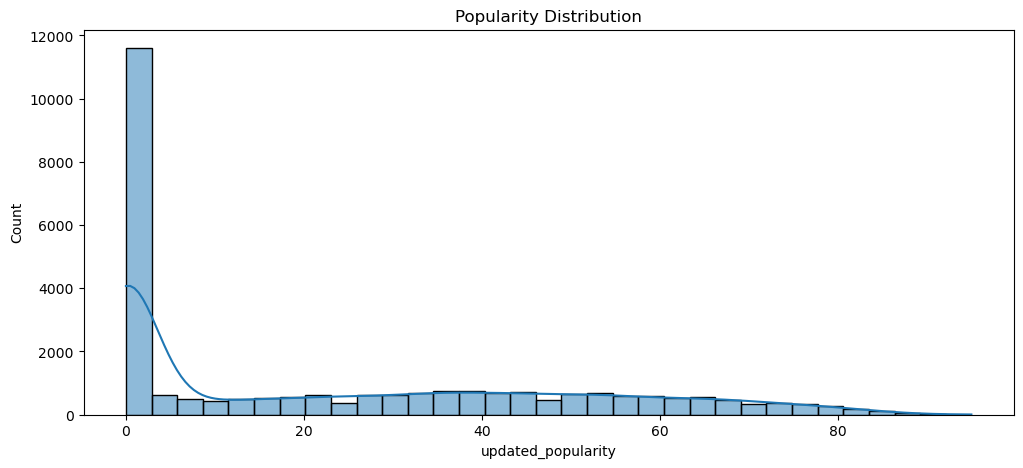

In [21]:
plt.figure(figsize=(12,5))
sns.histplot(df['updated_popularity'], kde=True)
plt.title("Popularity Distribution")
plt.show()

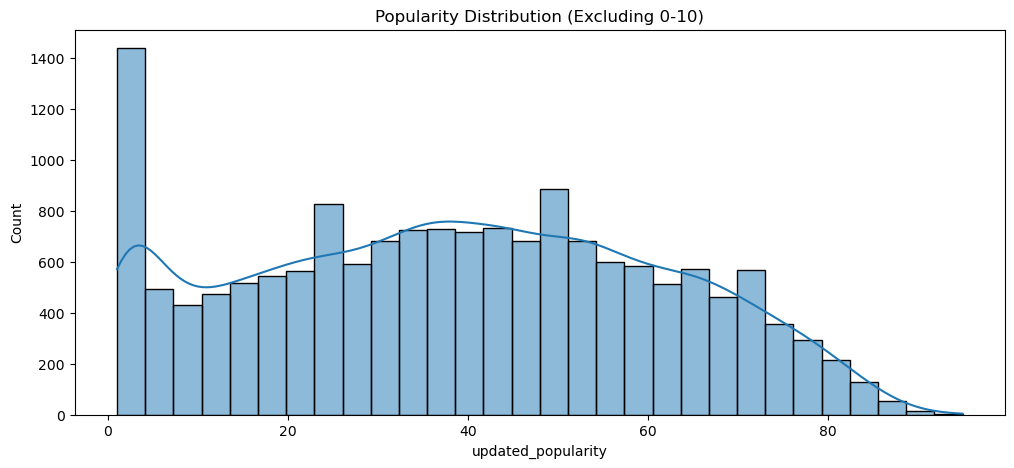

In [22]:
plt.figure(figsize=(12,5))
sns.histplot(df[df['updated_popularity']>0]['updated_popularity'], kde=True, bins=30)
plt.title("Popularity Distribution (Excluding 0-10)")
plt.show()

In [23]:
count_zero = (df["updated_popularity"] > 80).sum()
total = len(df)
print(count_zero)
print(f"{count_zero} rows out of {total} ({count_zero/total:.2%}) have updated_popularity == 0")

335
335 rows out of 26671 (1.26%) have updated_popularity == 0


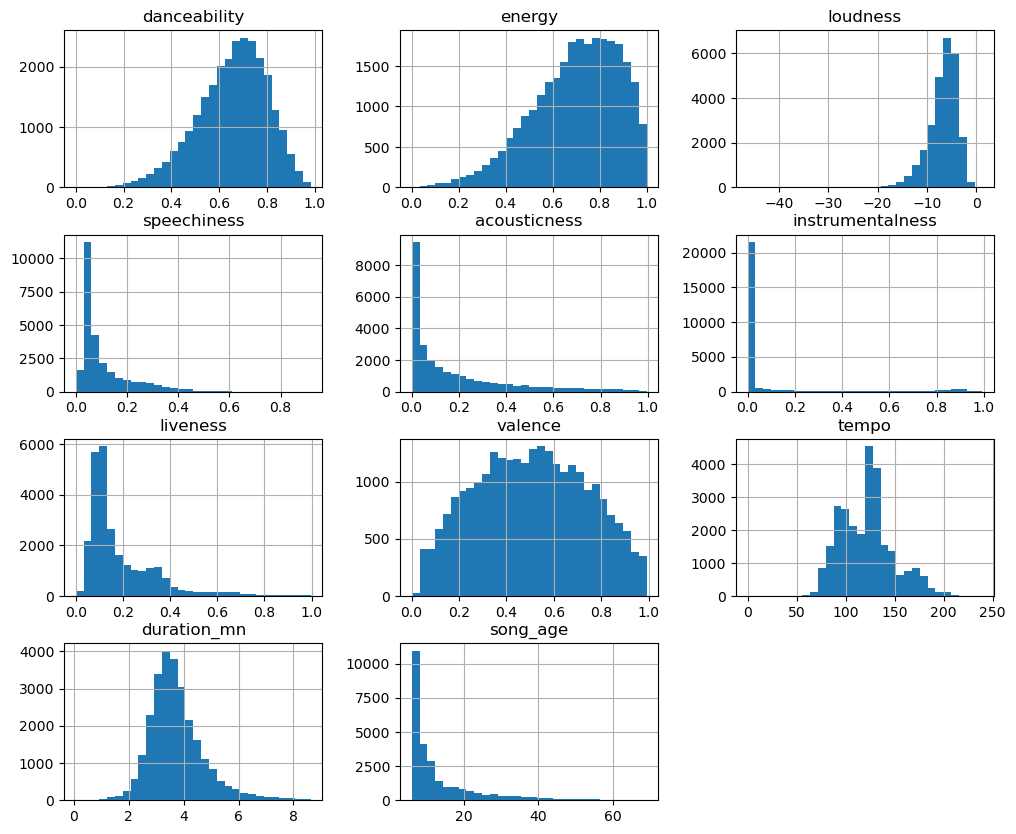

In [24]:
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo','duration_mn','song_age']

df[audio_features].hist(figsize=(12,10), bins=30)
plt.show()

/tmp/ipykernel_415/909214725.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values[:-1], y=corr.index[:-1], palette="viridis")


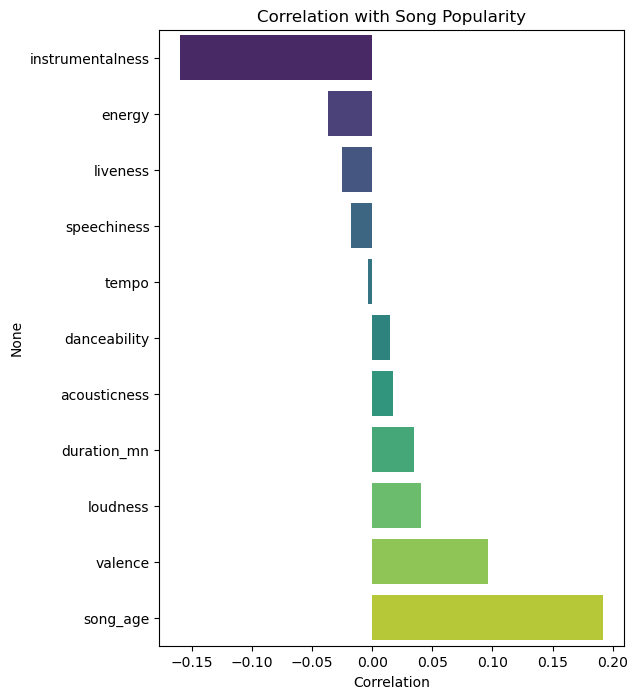

In [25]:
features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_mn", "song_age"
]

corr = df[features + ["updated_popularity"]].corr()["updated_popularity"].sort_values()

plt.figure(figsize=(6, 8))
sns.barplot(x=corr.values[:-1], y=corr.index[:-1], palette="viridis")
plt.title("Correlation with Song Popularity")
plt.xlabel("Correlation")
plt.show()

In [26]:
df = df[df["updated_popularity"] > 0].copy()

In [27]:
df.shape

(16050, 32)

In [32]:
df.to_csv( "../data/processed/spotify_songs_processed.csv",index=False)

# **EDA Summary**
The exploratory analysis reveals only weak relationships between audio features and song popularity. Correlation analysis and scatter plots indicate that no single audio characteristic strongly explains popularity. In contrast, audio features are strongly correlated with each other, suggesting redundancy among predictors. These results suggest that song popularity is largely driven by non-audio factors such as exposure, marketing, and recency effects, making popularity prediction from audio features alone a challenging task.